# Step 1: Setup prerequisites

In [1]:
import os
import sys
from pymongo import MongoClient

# utils에서 임포트하기 위해 부모 디렉토리를 경로에 추가합니다
sys.path.append(os.path.join(os.path.dirname(os.getcwd())))
from utils import set_env

In [2]:
# 본인의 MongoDB Atlas 클러스터를 사용하는 경우, 클러스터 연결 문자열을 여기에 입력하세요
MONGODB_URI = os.getenv("MONGODB_URI")
# MongoDB Python 클라이언트 초기화
mongodb_client = MongoClient(MONGODB_URI)
# 서버 연결 확인
mongodb_client.admin.command("ping")

{'ok': 1.0,
 '$clusterTime': {'clusterTime': Timestamp(1773405469, 1),
  'signature': {'hash': b'\xd6IDc\xa7\x80\xb5\xc7\xd4\xb6\x86\xd4\x8c\xfe\x82\xc5\x1a!\x80\\',
   'keyId': 7616710838270820359}},
 'operationTime': Timestamp(1773405469, 1)}

In [3]:
# 워크숍 강사로부터 제공받은 패스키를 설정하세요
PASSKEY = "replace-with-passkey"

In [4]:
# AI 모델 프록시에서 Voyage API 키를 가져와 환경변수로 설정합니다 -- 변경하지 마세요
set_env(["voyageai"], PASSKEY)

Successfully set VOYAGE_API_KEY environment variable.


# Step 2: Import data into MongoDB

In [5]:
import json

### **Do not change the values assigned to the variables below**

In [6]:
# 데이터베이스 이름
DB_NAME = "mongodb_genai_devday_vs"
# 컬렉션 이름
COLLECTION_NAME = "books"
# 벡터 검색 인덱스 이름
ATLAS_VECTOR_SEARCH_INDEX_NAME = "vector_index"

In [8]:
# `COLLECTION_NAME` 컬렉션에 연결합니다
collection = mongodb_client[DB_NAME][COLLECTION_NAME]
print(collection)

Collection(Database(MongoClient(host=['mongodb:27017'], document_class=dict, tz_aware=False, connect=True), 'mongodb_genai_devday_vs'), 'books')


In [11]:
with open("../data/books.json", "r") as data_file:
    json_data = data_file.read()

data = json.loads(json_data)

print(f"Deleting existing documents from the {COLLECTION_NAME} collection.")
collection.delete_many({})
collection.insert_many(data)
print(
    f"{collection.count_documents({})} documents ingested into the {COLLECTION_NAME} collection."
)

Deleting existing documents from the books collection.
20 documents ingested into the books collection.


# Step 3: Generating embeddings

In [12]:
from PIL import Image
import requests
import voyageai

In [13]:
# Voyage AI 클라이언트 초기화
vo = voyageai.Client()

### For images

📚 https://docs.voyageai.com/docs/multimodal-embeddings#python-api (See the Example)

In [14]:
image_url = "https://images.isbndb.com/covers/4318463482198.jpg"
# 위 URL에서 이미지를 불러옵니다
image = Image.open(requests.get(image_url, stream=True).raw)
# Voyage AI API의 `multimodal_embed` 메서드로 이미지를 임베딩합니다:
# inputs: 리스트의 리스트로 감싼 이미지
# model: `voyage-multimodal-3.5`
embedding = vo.multimodal_embed(inputs=[[image]], model="voyage-multimodal-3.5")

In [15]:
# `embedding` 객체에서 임베딩을 리스트로 가져옵니다
embedding.embeddings[0]

[-0.02734375,
 -0.01092529296875,
 -0.01513671875,
 -0.0179443359375,
 -0.0791015625,
 -0.006134033203125,
 0.0206298828125,
 0.01019287109375,
 0.0087890625,
 -0.06298828125,
 -0.02685546875,
 0.0286865234375,
 0.04638671875,
 0.01007080078125,
 0.031982421875,
 -0.0419921875,
 -0.0260009765625,
 0.0250244140625,
 -0.01031494140625,
 -0.03369140625,
 -0.0419921875,
 -0.0289306640625,
 0.053466796875,
 -0.000949859619140625,
 -0.0311279296875,
 -0.0224609375,
 0.00970458984375,
 0.0145263671875,
 0.018798828125,
 0.00072479248046875,
 0.004638671875,
 0.0771484375,
 -0.033447265625,
 0.055419921875,
 0.021484375,
 0.0223388671875,
 0.0086669921875,
 0.03466796875,
 -0.0272216796875,
 0.007049560546875,
 -0.04296875,
 -0.0478515625,
 -0.00494384765625,
 -0.025390625,
 0.00347900390625,
 -0.012939453125,
 -0.0478515625,
 0.00830078125,
 0.0267333984375,
 0.025390625,
 0.0245361328125,
 -0.0115966796875,
 -0.018798828125,
 -0.0250244140625,
 -0.01446533203125,
 -0.00994873046875,
 0.00509

### For text

In [17]:
text = "Puppy Preschool: Raising Your Puppy Right---Right from the Start!"
# `multimodal_embed` 메서드로 텍스트를 임베딩합니다
embedding = vo.multimodal_embed(inputs=[[text]], model="voyage-multimodal-3.5")

In [18]:
# `embedding` 객체에서 임베딩을 리스트로 가져옵니다
embedding.embeddings[0]

[0.0274658203125,
 0.027587890625,
 -0.0225830078125,
 -0.006805419921875,
 0.0015411376953125,
 0.057373046875,
 -0.01312255859375,
 -0.013916015625,
 0.01190185546875,
 0.017333984375,
 0.0087890625,
 -0.0458984375,
 0.004852294921875,
 0.00634765625,
 0.0311279296875,
 0.0135498046875,
 -0.01165771484375,
 -0.01287841796875,
 0.0225830078125,
 -0.018310546875,
 0.05419921875,
 0.0096435546875,
 0.01483154296875,
 -0.037353515625,
 0.034423828125,
 -0.0286865234375,
 0.004852294921875,
 0.056884765625,
 0.01904296875,
 0.04931640625,
 -0.0152587890625,
 -0.0172119140625,
 0.00262451171875,
 -0.0096435546875,
 0.00909423828125,
 0.03857421875,
 -0.015625,
 0.0361328125,
 -0.0023345947265625,
 0.0302734375,
 -0.058349609375,
 0.076171875,
 0.03369140625,
 0.01422119140625,
 0.06884765625,
 0.04736328125,
 -0.054443359375,
 0.0194091796875,
 -0.080078125,
 0.054931640625,
 -0.039794921875,
 -0.02099609375,
 -0.05322265625,
 -0.00439453125,
 0.0030059814453125,
 -0.053466796875,
 0.01562

# Step 4: Adding embeddings to existing data in Atlas

In [19]:
# 이 셀 실행 시 경고가 표시될 수 있습니다 -- 무시해도 됩니다
from typing import List, Dict, Optional
from tqdm import tqdm

In [20]:
# 임베딩할 필드 -- 이 경우 책 표지 이미지
field_to_embed = "cover"
# 문서에 추가할 임베딩 필드 이름
embedding_field = "embedding"

In [23]:
def get_embeddings(content: str, mode: str, input_type: str) -> List[float]:
    """
    임베딩 생성

    Args:
        content (str): 임베딩할 콘텐츠
        mode (str): 콘텐츠 모드 ("image" 또는 "text" 중 하나)
        input_type (str): 입력 유형, "document" 또는 "query"

    Returns:
        List[float]: 리스트 형태의 임베딩 벡터
    """
    # 입력이 이미지인 경우 이미지 콘텐츠를 먼저 로드합니다
    if mode == "image":
        if content.startswith("http"):
            content = Image.open(requests.get(content, stream=True).raw)
        else:
            content = Image.open(content)
    return vo.multimodal_embed(inputs=[[content]], model="voyage-multimodal-3.5", input_type=input_type).embeddings[0]

📚 https://www.mongodb.com/docs/manual/tutorial/query-documents/#select-all-documents-in-a-collection

In [24]:
# `collection` 컬렉션의 모든 문서를 조회합니다
results = collection.find({})

📚 **$set:** https://www.mongodb.com/docs/manual/reference/operator/update/set/#syntax

📚 **update_one():** https://pymongo.readthedocs.io/en/stable/api/pymongo/collection.html#pymongo.collection.Collection.update_one

In [25]:
# `collection` 컬렉션의 각 문서에 임베딩을 추가합니다
for result in tqdm(results):
    content = result[field_to_embed]
    # 위에서 정의한 `get_embeddings` 함수로 `content`를 임베딩합니다
    # `content`는 책 표지 이미지이므로 `mode`를 적절히 설정합니다
    # 검색 대상 문서를 임베딩하므로 `input_type`을 "document"로 설정합니다
    embedding = get_embeddings(content, "image", "document")
    # `_id` 필드로 현재 문서를 특정하는 필터를 만듭니다
    filter = {"_id": result["_id"]}
    # `$set` 연산자로 `embedding_field` 필드에 임베딩 값을 설정합니다
    update = {"$set": {embedding_field: embedding}}
    # `update_one()` 연산으로 문서를 인플레이스 업데이트합니다
    # `filter`로 올바른 `_id`를 찾고 `update`를 적용합니다
    collection.update_one(filter, update)

20it [00:40,  2.04s/it]


# Step 5: Create a vector search index

In [26]:
from utils import create_index, check_index_ready

In [27]:
# 벡터 인덱스 정의를 생성합니다:
# path: 임베딩 필드 경로
# numDimensions: 임베딩 차원 수 (사용하는 임베딩 모델에 따라 다름)
# similarity: 유사도 측정 방식. cosine, euclidean, dotProduct 중 하나
model = {
    "name": ATLAS_VECTOR_SEARCH_INDEX_NAME,
    "type": "vectorSearch",
    "definition": {
        "fields": [
            {
                "type": "vector",
                "path": "embedding",
                "numDimensions": 1024,
                "similarity": "cosine",
            }
        ]
    },
}

In [ ]:
# Step 4에서 각 문서에 저장해둔 `embedding` 필드를 기반으로
# MongoDB가 내부적으로 벡터 검색 인덱스를 생성합니다.
# 이 인덱스가 있어야 이후 $vectorSearch 쿼리로 유사한 문서를 빠르게 찾을 수 있습니다.
# (확인: mongosh에서 db.books.listSearchIndexes() 로 생성된 인덱스를 조회할 수 있습니다)
create_index(collection, ATLAS_VECTOR_SEARCH_INDEX_NAME, model)

In [ ]:
# 생성된 벡터 검색 인덱스를 조회합니다
# 참고: 벡터 검색 인덱스는 일반 인덱스(collection.index_information())와 별도로 관리됩니다
#       반드시 list_search_indexes()로 조회해야 합니다
list(collection.list_search_indexes())

In [ ]:
# `utils` 모듈의 `check_index_ready` 함수로 인덱스가 생성되고 READY 상태인지 확인한 후 진행합니다
# create_search_index()는 비동기로 동작합니다.
# 함수가 리턴된 시점에 인덱스가 아직 생성 중일 수 있으므로,
# $vectorSearch 쿼리 실행 전에 READY 상태가 될 때까지 폴링합니다.
# 인덱스 상태 흐름: PENDING → BUILDING → READY
check_index_ready(collection, ATLAS_VECTOR_SEARCH_INDEX_NAME)

# 벡터 검색으로 사용자 쿼리에 관련된 문서를 조회하는 함수를 정의합니다
def vector_search(
    user_query: str, mode: str, filter: Optional[Dict] = {}
) -> None:
    """
    벡터 검색으로 사용자 쿼리에 관련된 문서를 조회합니다.

    Args:
    user_query (str): 사용자 쿼리 (텍스트 또는 이미지 링크)
    mode (str): 쿼리 모드 (image 또는 text)
    filter (Optional[Dict], optional): 벡터 검색 사전 필터 (선택 사항)
    """
    # 사용자 쿼리를 벡터로 변환합니다 (검색 기준이 되는 벡터)
    # 쿼리를 임베딩하므로 input_type을 "query"로 설정합니다
    query_embedding = get_embeddings(user_query, mode, "query")

    # 집계 파이프라인: 데이터가 아래 단계를 순서대로 통과합니다
    #
    # Stage 1 - $vectorSearch: 벡터 유사도 검색
    #   - 전체 문서 중 query_embedding과 가장 유사한 후보 20개를 뽑고
    #   - filter 조건을 만족하는 문서만 남긴 후 상위 5개를 반환합니다
    #
    # Stage 2 - $project: 필요한 필드만 추출
    #   - 1: 포함 / 0: 제외
    #   - vectorSearchScore: 벡터 검색이 계산한 유사도 점수 (특수 문법 $meta 사용)
    pipeline = [
        {
            "$vectorSearch": {
                "index": ATLAS_VECTOR_SEARCH_INDEX_NAME,  # 사용할 벡터 인덱스
                "queryVector": query_embedding,            # 검색 기준 벡터
                "path": "embedding",                       # 문서에서 비교할 임베딩 필드
                "numCandidates": 20,                       # 후보 수 (많을수록 정확하지만 느림)
                "filter": filter,                          # 사전 필터 (예: year >= 2002)
                "limit": 5,                                # 최종 반환할 문서 수
            }
        },
        {
            "$project": {
                "_id": 0,                                          # 제외
                "title": 1,                                        # 포함
                "cover": 1,                                        # 포함
                "year": 1,                                         # 포함
                "pages": 1,                                        # 포함
                "score": {"$meta": "vectorSearchScore"},           # 유사도 점수 추출
            }
        },
    ]

    # 집계 파이프라인을 실행하고 결과를 results에 저장합니다
    results = collection.aggregate(pipeline)

    # 책 제목, 점수, 표지 이미지를 출력합니다
    for book in results:
        cover = Image.open(requests.get(book.get("cover"), stream=True).raw).resize((100,150))
        print(f"{book.get('title')}({book.get('year')}, {book.get('pages')} pages): {book.get('score')}")
        display(cover)

# Step 6: Perform vector search queries

📚 https://www.mongodb.com/docs/atlas/atlas-vector-search/vector-search-stage/#ann-examples (Refer to the "ANN Filter Example")

In [36]:
# 벡터 검색으로 사용자 쿼리에 관련된 문서를 조회하는 함수를 정의합니다
def vector_search(
    user_query: str, 
    mode: str, 
    filter: Optional[Dict] = {}
) -> None:
    """
    벡터 검색으로 사용자 쿼리에 관련된 문서를 조회합니다.

    Args:
    user_query (str): 사용자 쿼리 (텍스트 또는 이미지 링크)
    mode (str): 쿼리 모드 (image 또는 text)
    filter (Optional[Dict], optional): 벡터 검색 사전 필터 (선택 사항)
    """
    # Step 4에서 정의한 `get_embeddings` 함수로 `user_query`를 임베딩합니다
    # 쿼리를 임베딩하므로 `input_type`을 "query"로 설정합니다
    query_embedding = get_embeddings(user_query, mode, "query")

    # 집계 파이프라인: 데이터가 아래 단계를 순서대로 통과합니다
    #
    # Stage 1 - $vectorSearch: 벡터 유사도 검색
    #   - 전체 문서 중 query_embedding과 가장 유사한 후보 20개를 뽑고
    #   - filter 조건을 만족하는 문서만 남긴 후 상위 5개를 반환합니다
    #
    # Stage 2 - $project: 필요한 필드만 추출
    #   - 1: 포함 / 0: 제외
    #   - vectorSearchScore: 벡터 검색이 계산한 유사도 점수 (특수 문법 $meta 사용)
    #
    # $vectorSearch 스테이지와 $project 스테이지로 구성된 집계 파이프라인을 정의합니다
    # 후보 수는 20개로 설정하고 상위 5개만 반환합니다
    # $vectorSearch 스테이지의 `filter` 필드에 함수로 전달된 `filter` 값을 설정합니다
    # $project 스테이지에서 `_id`는 제외하고 `title`, `cover`, `year`, `pages`, `vectorSearchScore`를 포함합니다
    # 참고: `index`, `queryVector`, `path` 필드에는 앞서 정의한 변수를 사용합니다
    pipeline = [
        {
            "$vectorSearch": {
                "index": ATLAS_VECTOR_SEARCH_INDEX_NAME,   # 사용할 벡터 인덱스
                "queryVector": query_embedding,            # 검색 기준 벡터
                "path": "embedding",                       # 문서에서 비교할 임베딩 필드
                "numCandidates": 20,                       # 후보 수 (많을수록 정확하지만 느림)
                "filter": filter,                          # 사전 필터 (예: year >= 2002)
                "limit": 5,                                # 최종 반환할 문서 수
            }
        },
        {
            "$project": {
                "_id": 0,                                          # 제외
                "title": 1,                                        # 포함
                "cover": 1,                                        # 포함
                "year": 1,                                         # 포함
                "pages": 1,                                        # 포함
                "score": {"$meta": "vectorSearchScore"},           # 유사도 점수 추출
            }
        },
    ]

    # 집계 `pipeline`을 실행하고 결과를 `results`에 저장합니다
    results = collection.aggregate(pipeline)

    # 책 제목, 점수, 표지 이미지를 출력합니다
    for book in results:
        cover = Image.open(requests.get(book.get("cover"), stream=True).raw).resize((100,150))
        print(f"{book.get('title')}({book.get('year')}, {book.get('pages')} pages): {book.get('score')}")
        display(cover)

King Lear (Oxford School Shakespeare Series)(2002, 224 pages): 0.6269742250442505


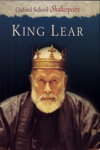

David Copperfield's Tales of the Impossible(1995, 385 pages): 0.5751422047615051


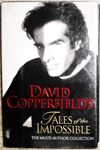

My Favorite Summer 1956(1991, 246 pages): 0.5666068196296692


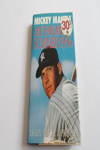

The Hobbit(1986, 320 pages): 0.5573791861534119


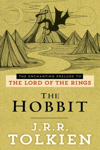

Watership Down(1975, 478 pages): 0.5462617874145508


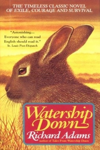

In [38]:
# 텍스트 쿼리로 벡터 검색을 테스트합니다
vector_search("A man wearing a golden crown", "text")

# 다음 텍스트 쿼리도 시도해보세요:
# - A rainbow of lively colors
# - Creatures wondrous or familiar
# - A boy and the ocean
# - Houses

In [ ]:
# 이미지 쿼리로 벡터 검색을 테스트합니다
vector_search("https://images.isbndb.com/covers/10835953482746.jpg", "image")

# 다음 이미지 쿼리도 시도해보세요:
# - ../data/images/salad.jpg
# - ../data/images/kitten.png
# - ../data/images/barn.png

# Step 7: Adding pre-filters to your vector search

### Filter for books that were published after the year `2002`

📚 https://www.mongodb.com/docs/atlas/atlas-vector-search/vector-search-type/#about-the-filter-type

In [ ]:
# Step 5의 벡터 검색 인덱스 `model`을 수정하여 `year` 필드를 `filter` 필드로 추가합니다
model = {
    "name": ATLAS_VECTOR_SEARCH_INDEX_NAME,
    "type": "vectorSearch",
    "definition": {
        "fields": [
            {
                "type": "vector",
                "path": "embedding",
                "numDimensions": 1024,
                "similarity": "cosine",
            },
            {"type": "filter", "path": "year"},
        ]
    },
}

In [ ]:
# `utils` 모듈의 `create_index` 함수로 수정된 모델로 벡터 검색 인덱스를 재생성합니다
create_index(collection, ATLAS_VECTOR_SEARCH_INDEX_NAME, model)

In [ ]:
# `utils` 모듈의 `check_index_ready` 함수로 인덱스에 올바른 필터 필드가 있고 READY 상태인지 확인한 후 진행합니다
check_index_ready(collection, ATLAS_VECTOR_SEARCH_INDEX_NAME)

📚 https://www.mongodb.com/docs/manual/reference/operator/query/gte/#syntax

In [ ]:
# `$gte` 연산자를 사용하여 `year` 필드가 2002 이상인 책을 필터링하는 필터 정의를 만듭니다
filter = {"year": {"$gte": 2002}}
# `vector_search` 함수에 `filter`를 인자로 전달합니다
# `vector_search` 함수 내 `pipeline`에 이 필터가 어떻게 반영되는지 확인해보세요
vector_search("A boy and the ocean", "text", filter)

### Filter for books that were published after the year `2002` and under `250` pages

📚 https://www.mongodb.com/docs/atlas/atlas-vector-search/vector-search-type/#about-the-filter-type

In [ ]:
# Step 5의 벡터 검색 인덱스 `model`을 수정하여 `year`와 `pages`를 필터 필드로 추가합니다
model = {
    "name": ATLAS_VECTOR_SEARCH_INDEX_NAME,
    "type": "vectorSearch",
    "definition": {
        "fields": [
            {
                "type": "vector",
                "path": "embedding",
                "numDimensions": 1024,
                "similarity": "cosine",
            },
            {"type": "filter", "path": "year"},
            {"type": "filter", "path": "pages"},
        ]
    },
}

In [ ]:
# `utils` 모듈의 `create_index` 함수를 사용하여 수정된 모델로 벡터 검색 인덱스를 재생성합니다
create_index(collection, ATLAS_VECTOR_SEARCH_INDEX_NAME, model)

In [ ]:
# `utils` 모듈의 `check_index_ready` 함수로 인덱스에 올바른 필터 필드가 있고 READY 상태인지 확인한 후 진행합니다
check_index_ready(collection, ATLAS_VECTOR_SEARCH_INDEX_NAME)

📚 https://www.mongodb.com/docs/manual/reference/operator/query/lte/#mongodb-query-op.-lte

In [ ]:
# `year` 필드가 2002 이상이고 `pages` 필드가 250 이하인 책을 필터링하는 정의를 만듭니다
# `$gte`와 `$lte` 연산자를 사용합니다
filter = {"$and": [{"year": {"$gte": 2002}}, {"pages": {"$lte": 250}}]}
# `vector_search` 함수에 `filter`를 인자로 전달합니다
# `vector_search` 함수 내 `pipeline`에 이 필터가 어떻게 반영되는지 확인해보세요
vector_search("A boy and the ocean", "text", filter)

# Step 8: Enable vector quantization

📚 https://www.mongodb.com/docs/atlas/atlas-vector-search/vector-search-type/#syntax

In [ ]:
# Step 5의 벡터 검색 인덱스 `model`을 수정하여 `scalar` 양자화를 사용하도록 합니다
model = {
    "name": ATLAS_VECTOR_SEARCH_INDEX_NAME,
    "type": "vectorSearch",
    "definition": {
        "fields": [
            {
                "type": "vector",
                "path": "embedding",
                "numDimensions": 1024,
                "similarity": "cosine",
                "quantization": "scalar",
            },
        ]
    },
}

# 🦹‍♀️ Hybrid search

## 일반 벡터 검색 vs 하이브리드 검색

### 일반 벡터 검색 (`$vectorSearch`)
**의미적 유사도**만 사용합니다.
- 강점: 단어가 달라도 의미가 비슷하면 찾아냄
- 약점: 정확한 키워드가 중요한 경우 놓칠 수 있음

### 하이브리드 검색 (`$rankFusion`)
**벡터 검색 + 전문 검색(Full-Text Search)** 결과를 합산합니다.

`vector_weight`, `full_text_weight`로 각 검색의 비중을 조절할 수 있습니다.

| | 벡터 검색 | 하이브리드 검색 |
|---|---|---|
| 검색 방식 | 의미적 유사도 | 유사도 + 키워드 |
| 인덱스 | `vectorSearch` 1개 | `vectorSearch` + `search` 2개 |
| 연산자 | `$vectorSearch` | `$rankFusion` |
| 적합한 경우 | 이미지, 자연어 의미 검색 | 키워드 정확도도 중요한 경우 |

> **한 줄 요약**: 벡터 검색은 "느낌이 비슷한 것", 하이브리드는 "느낌도 비슷하고 단어도 맞는 것"을 찾습니다.

In [ ]:
# `utils` 모듈의 `check_index_ready` 함수를 사용하여 양자화가 적용된 인덱스가 생성되었는지 확인합니다
check_index_ready(collection, ATLAS_VECTOR_SEARCH_INDEX_NAME)

# 🦹‍♀️ Hybrid search

In [ ]:
# 전문 검색 인덱스 이름
ATLAS_FTS_INDEX_NAME = "fts_index"

In [ ]:
# 필드 매핑을 지정하는 전문 검색 인덱스 정의를 생성합니다
model = {
    "name": ATLAS_FTS_INDEX_NAME,
    "type": "search",
    "definition": {
        "mappings": {"dynamic": False, "fields": {"synopsis": {"type": "string"}}}
    },
}

In [ ]:
# `utils` 모듈의 `create_index` 함수를 사용하여 `collection` 컬렉션에 위 정의로 전문 검색 인덱스를 생성합니다
create_index(collection, ATLAS_FTS_INDEX_NAME, model)

In [ ]:
# 벡터 검색 인덱스를 원래 정의로 초기화합니다
model = {
    "name": ATLAS_VECTOR_SEARCH_INDEX_NAME,
    "type": "vectorSearch",
    "definition": {
        "fields": [
            {
                "type": "vector",
                "path": "embedding",
                "numDimensions": 1024,
                "similarity": "cosine",
            }
        ]
    },
}

# `utils` 모듈의 `create_index` 함수를 사용하여 벡터 검색 인덱스를 초기 정의로 재설정합니다
create_index(collection, ATLAS_VECTOR_SEARCH_INDEX_NAME, model)

In [ ]:
# `utils` 모듈의 `check_index_ready` 함수를 사용하여 두 인덱스가 생성되고 READY 상태인지 확인한 후 진행합니다
check_index_ready(collection, ATLAS_VECTOR_SEARCH_INDEX_NAME)
check_index_ready(collection, ATLAS_FTS_INDEX_NAME)

**NOTE:** Refer to our [documentation](https://www.mongodb.com/docs/atlas/atlas-vector-search/tutorials/reciprocal-rank-fusion/#about-the-query) for a detailed explanation of the hybrid search query below.

In [ ]:
def hybrid_search(
    user_query: str, vector_weight: float, full_text_weight: float
) -> None:
    """
    하이브리드 검색으로 사용자 쿼리에 관련된 문서를 조회합니다.

    Args:
        user_query (str): 사용자 쿼리 문자열
        vector_weight (float): 최종 검색 결과에서 벡터 검색의 가중치
        full_text_weight (float): 최종 검색 결과에서 전문 검색의 가중치
    """
    pipeline = [
        {
            "$rankFusion": {
                "input": {
                    "pipelines": {
                        # 벡터 검색 파이프라인
                        "vector_pipeline": [
                            {
                                "$vectorSearch": {
                                    "index": ATLAS_VECTOR_SEARCH_INDEX_NAME,
                                    "path": "embedding",
                                    "queryVector": get_embeddings(user_query, "text", "query"),
                                    "numCandidates": 20,
                                    "limit": 10,
                                }
                            }
                        ],
                        # 전문 검색 파이프라인
                        "fts_pipeline": [
                            {
                                "$search": {
                                    "index": ATLAS_FTS_INDEX_NAME,
                                    "text": {"query": user_query, "path": "synopsis"},
                                }
                            },
                            {"$limit": 10},
                        ],
                    }
                },
                # 벡터 검색과 전문 검색 파이프라인의 점수를 결합합니다
                "combination": {
                    "weights": {"vector_pipeline": vector_weight, "fts_pipeline": full_text_weight}
                },
                "scoreDetails": True,
            }
        },
        {
            "$project": {
                "_id": 0,
                "title": 1,
                "cover": 1,
                "score": {"$getField": {"field": "value", "input": {"$meta": "scoreDetails"}}},
            }
        },
        {"$limit": 5},
    ]

    results = collection.aggregate(pipeline)
    # 책 제목, 하이브리드 검색 점수, 표지 이미지를 출력합니다
    for book in results:
        cover = Image.open(requests.get(book["cover"], stream=True).raw).resize(
            (100, 150)
        )
        print(
            f"{book.get('title')}, Hybrid Search Score: {book.get('score')}"
        )
        display(cover)

In [ ]:
# 벡터 검색 가중치 1.0, 전문 검색 가중치 0.0으로 하이브리드 검색을 테스트합니다
hybrid_search(
    user_query="Magic and fantasy",
    vector_weight=1.0,
    full_text_weight=0.0,
)

In [ ]:
# 벡터 검색 가중치 0.3, 전문 검색 가중치 0.7로 하이브리드 검색을 테스트합니다
hybrid_search(
    user_query="Magic and fantasy",
    vector_weight=0.3,
    full_text_weight=0.7,
)